
--- QLattice Performance on Acidic pKa Dataset ---
Test R²: 0.183


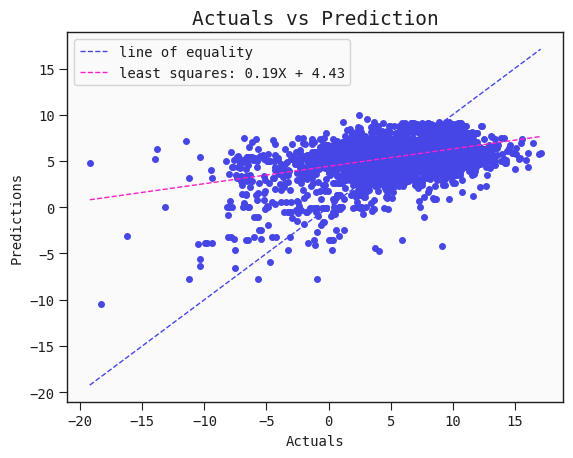

In [1]:
# --- Load + Prepare pKa + Descriptors from Acidic pKa Data ---
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem.SaltRemover import SaltRemover
from rdkit.Chem import Descriptors
from tqdm import tqdm
import logging
from func_timeout import func_timeout, FunctionTimedOut
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import feyn

# Logging for debugging descriptor calc issues
logging.basicConfig(filename='descriptor_errors.log', level=logging.INFO,
                    format='%(asctime)s:%(levelname)s:%(message)s')

# Load the acidic pKa dataset
acidic_file = "acidic_pKa_data.csv"
smiles_col = 'SMILES'
target = 'pka_value'

df = pd.read_csv(acidic_file)
df[target] = pd.to_numeric(df[target], errors='coerce')  # Ensure target is numeric

# Salt remover setup
saltRemover = SaltRemover(defnFilename='./Salts.txt')

# Convert SMILES to Mol objects and strip salts
df['Mol'] = df[smiles_col].astype(str).apply(
    lambda s: saltRemover.StripMol(Chem.MolFromSmiles(s))
)

# Descriptor calculation utilities
def safe_call(func, mol, timeout=1):
    try:
        return func_timeout(timeout, func, args=(mol,))
    except (FunctionTimedOut, Exception) as e:
        logging.info(f"Error in {func.__name__}: {e}")
        return np.nan

def compute_descriptors_for_mol(mol):
    descriptor_funcs = {name: func for name, func in Descriptors.descList}
    if mol is None or Chem.MolToSmiles(mol) == '':
        return None
    desc_values = {}
    for name, func in descriptor_funcs.items():
        value = safe_call(func, mol, timeout=1)
        desc_values[name] = value
    return desc_values

def compute_descriptors_for_df(df):
    desc_list = []
    mols = df['Mol'].tolist()
    for mol in tqdm(mols, desc="Computing descriptors"):
        result = compute_descriptors_for_mol(mol)
        desc_list.append(result if result is not None else {})
    desc_df = pd.DataFrame(desc_list)
    desc_df = desc_df.dropna(how='all').reset_index(drop=True)
    desc_df = desc_df.loc[:, desc_df.std() > 0]  # drop zero-variance columns
    df_reset = df.reset_index(drop=True)
    combined = pd.concat([df_reset[[target]].reset_index(drop=True), desc_df], axis=1)
    return combined.dropna()

# Generate full dataset with descriptors
data = compute_descriptors_for_df(df)

# Split into 75% train, 25% test
train_data, test_data = train_test_split(data, test_size=0.25, random_state=42)

# Run QLattice with best-known parameters
ql = feyn.QLattice()
models = ql.auto_run(train_data, output_name=target, n_epochs=200, threads=16, max_complexity=200, criterion='bic')

# Evaluate the best model
best_model = models[0]
y_true = test_data[target].values
y_pred = best_model.predict(test_data)
r2 = r2_score(y_true, y_pred)

print("\n--- QLattice Performance on Acidic pKa Dataset ---")
print(f"Test R²: {r2:.3f}")
best_model.plot(train_data, test_data)
best_model.plot_regression(test_data)


In [2]:
best_model.plot(train, test)

NameError: name 'train' is not defined

In [ ]:
sympy_model = best_model.sympify(signif=3)

sympy_model.as_expr()



In [ ]:
best_model.sympify(signif=3).as_coeff_exponent